# Dask Delayed

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Лекция "Dask Delayed"
* https://docs.dask.org/en/latest/delayed.html
* Jesse C. Daniel. Data Science with Python and Dask.
* https://saturncloud.io/blog/a-data-scientist-s-guide-to-lazy-evaluation-with-dask/
* https://www.coiled.io/blog/how-to-learn-dask-in-2021
* https://realpython.com/python-concurrency/

## Задачи для совместного разбора

1\. Напишите 2 функции, имитирующие CPU-bound задачу и IO-bound задачу:

`cpu_task()`: генерирует 100 тыс. случайных чисел и возвращает их сумму (без использования `numpy`)

`io_task()`: "спит" 0.1 сек, затем генерирует случайное число и возвращает его

Замерьте время выполнения 100 последовательных вызовов каждой из этих функций. Распараллелив вычисления при помощи `dask.delayed`, сократите время выполнения. Исследуйте, как зависит время вычислений от выбранного планировщика `scheduler`.

In [ ]:
import numpy as np
import dask.delayed as delayed
import dask
from time import sleep
import random

In [ ]:
def cpu_task():
    numbers = [random.randint(0, 100) for _ in range(100_000)]
    s = sum(numbers)
    return s

In [ ]:
def io_task():
    sleep(0.1)
    n = random.randint(0, 100)
    return n

In [ ]:
%%time
r = [cpu_task() for _ in range(100)]

CPU times: user 4.74 s, sys: 24.7 ms, total: 4.76 s
Wall time: 4.6 s


In [ ]:
%%time
r = [io_task() for _ in range(100)]

CPU times: user 8.04 ms, sys: 3.07 ms, total: 11.1 ms
Wall time: 10.4 s


In [ ]:
cpu_task_delayed = delayed(cpu_task)

In [ ]:
cpu_task_delayed().compute()

4995081

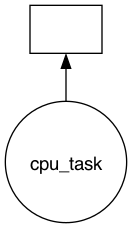

In [ ]:
d = cpu_task_delayed()
d.visualize()

## Лабораторная работа 14

<p class="task" id="1"></p>

1\. Напишите функцию `read_profiles`, которая считывает один файл формата xml из каталога `reviewers_full` и по данным этого файла формирует список словарей, содержащих следующие ключи: `id`, `username`, `name`, `sex`, `country`, `mail`, `registered`, `birthdate`, `name_prefix`, `country_code`. Часть из этих значений в исходном файле хранится в виде тэгов, часть - в виде атрибутов тэгов. Для конкретного человека какие-то из этих ключей могут отсутствовать.

Обработайте все файлы, вызвав последовательно вызвав эту функцию для каждого из них, и собрав результаты в один общий список словарей `profiles`. Измерьте время выполнения кода.

Выведите на экран уникальные значения по ключам `name_prefix` и `country_code`


```python
def read_profiles(file: str) -> list[dict]:
    pass
```

In [ ]:
import xml.etree.ElementTree as ET

def read_profiles(file: str) -> list[dict]:
    with open(file, "r") as f:
        xml = f.read()
    root = ET.fromstring(xml)
    profiles = []
    for profile in root:
        p = {'id': None, 'username': None, 'name': None, 'sex': None, 'country': None,
             'mail': None, 'registered': None, 'birthdate': None, 'name_prefix': None,
             'country_code': None}
        for field in profile:
            p[field.tag] = field.text
            if field.tag == 'country' and field.attrib:
                p['country_code'] = field.attrib['code']
            if field.tag == 'name' and field.text.split()[0][-1] == '.':
                p['name_prefix'] = field.text.split()[0]
        profiles.append(p)
    return profiles

In [ ]:
import os
files = os.listdir("data/reviewers_full")

In [ ]:
%%time
profiles = []
for file in files:
    profiles.extend(read_profiles(f"data/reviewers_full/{file}"))

CPU times: user 10.6 s, sys: 2.73 s, total: 13.3 s
Wall time: 14.3 s


In [ ]:
name_prefixes = set([p['name_prefix'] for p in profiles])
name_prefixes

{'Dr.', 'Mr.', 'Mrs.', 'Ms.', None}

In [ ]:
name_prefixes = set([p['country_code'] for p in profiles])
name_prefixes

{'AD',
 'AE',
 'AF',
 'AG',
 'AI',
 'AL',
 'AM',
 'AN',
 'AO',
 'AR',
 'AS',
 'AT',
 'AU',
 'AW',
 'AZ',
 'BA',
 'BB',
 'BD',
 'BE',
 'BF',
 'BG',
 'BH',
 'BI',
 'BJ',
 'BM',
 'BN',
 'BO',
 'BR',
 'BS',
 'BT',
 'BW',
 'BY',
 'BZ',
 'CA',
 'CC',
 'CF',
 'CH',
 'CK',
 'CL',
 'CM',
 'CN',
 'CO',
 'CR',
 'CU',
 'CV',
 'CX',
 'CY',
 'CZ',
 'DE',
 'DJ',
 'DK',
 'DM',
 'DO',
 'DZ',
 'EC',
 'EE',
 'EG',
 'EH',
 'ER',
 'ES',
 'ET',
 'FI',
 'FJ',
 'FK',
 'FO',
 'FR',
 'GA',
 'GB',
 'GD',
 'GE',
 'GF',
 'GG',
 'GH',
 'GI',
 'GL',
 'GM',
 'GN',
 'GP',
 'GQ',
 'GR',
 'GS',
 'GT',
 'GU',
 'GW',
 'GY',
 'HM',
 'HN',
 'HR',
 'HT',
 'HU',
 'ID',
 'IE',
 'IL',
 'IM',
 'IN',
 'IQ',
 'IR',
 'IS',
 'IT',
 'JE',
 'JM',
 'JO',
 'JP',
 'KE',
 'KH',
 'KI',
 'KM',
 'KN',
 'KW',
 'KY',
 'KZ',
 'LA',
 'LB',
 'LC',
 'LI',
 'LK',
 'LR',
 'LS',
 'LT',
 'LU',
 'LV',
 'LY',
 'MA',
 'MC',
 'ME',
 'MF',
 'MG',
 'MH',
 'ML',
 'MM',
 'MN',
 'MO',
 'MP',
 'MQ',
 'MR',
 'MS',
 'MT',
 'MU',
 'MV',
 'MW',
 'MX',
 'MY',
 'MZ',

<p class="task" id="2"></p>

2\. Задекорируйте функцию `read_profiles` при помощи `dask.delayed`. Cоздайте список `reviewers`, состоящий из 20 объектов `Delayed` (по одному объекту на файл). Повторите решение задачи 1, распараллелив вычисления при помощи `dask`. Измерьте время выполнения кода. Добейтесь существенного (в разы) уменьшения времени выполнения в сравнении с решением задачи 1.

In [ ]:
read_profiles_delayed = delayed(read_profiles)

In [ ]:
reviews = [read_profiles_delayed(f"data/reviewers_full/{file}") for file in files]

In [ ]:
%%time
results = dask.compute(reviews, scheduler='processes')

CPU times: user 570 ms, sys: 209 ms, total: 779 ms
Wall time: 3.05 s


<p class="task" id="3"></p>

3\. Задекорируйте функцию из задания 1 при помощи `dask.delayed` и создайте список `reviewers`, состоящий из 20 объектов `Delayed` (по одному объекту на файл). Из списка объектов `Delayed`, создайте `dask.bag` при помощи метода `db.from_delayed`. Добавьте ключ `birth_year`, в котором хранится год рождения человека. Оставьте в выборке только тех людей, которые __наверняка__ моложе 1980 года. Преобразуйте поле `id` к целому типу.

Выведите на экран количество элементов в созданном `Bag`.

In [ ]:
reviews = [read_profiles_delayed(f"data/reviewers_full/{file}") for file in files]

In [ ]:
import dask.bag as db

reviews_bag = db.from_delayed(reviews)

In [ ]:
reviews_bag.take(1)

({'id': '69728',
  'username': 'daviddixon',
  'name': None,
  'sex': 'M',
  'country': 'Singapore',
  'mail': 'james89@hotmail.com',
  'registered': '2004-03-02',
  'birthdate': '1980-10-30',
  'name_prefix': None,
  'country_code': 'SG',
  'birth_year': '1980'},)

In [ ]:
reviews_bag = reviews_bag.map(
    lambda person: {
        **person, "birth_year": person["birthdate"].split("-")[0] if person["birthdate"] else None
    }
)

In [ ]:
reviews_bag_younger_1980 = reviews_bag.filter(
    lambda person: person["birth_year"] and int(person["birth_year"]) > 1980
).map(
    lambda person: {**person, "id": int(person["id"])}
)

In [ ]:
reviews_bag_younger_1980.count().compute()

287501

<p class="task" id="4"></p>

4\. Преобразуйте `Bag` из предыдущего задания в `dd.DataFrame`. Найдите и выведите на экран страну с наибольшим количеством пользователей.

In [ ]:
import dask.dataframe as dd

reviews_df = reviews_bag_younger_1980.to_dataframe()

In [ ]:
reviews_df['country'].value_counts().compute()

Korea                1185
Congo                1146
Liberia               660
Brunei Darussalam     660
Gambia                658
                     ... 
Guadeloupe            540
Timor-Leste           538
Saint Martin          531
Saint Barthelemy      530
Bangladesh            514
Name: country, Length: 243, dtype: int64

In [ ]:
reviews_df.groupby("country")['id'].count().compute().sort_values(ascending=False).head(1)

country
Congo    4089
Name: id, dtype: int64

<p class="task" id="5"></p>

5\. Даны две функции: `get_product` и `add_to_db`. Воспользовавшись функцией `get_product`, получите список из 16 товаров с ID от 1 до 16. Добавьте каждый товар в БД __по отдельности__ при помощи функции `add_to_db`. Посчитайте общую сумму добавленных товаров и выведите ее на экран. Замерьте время выполнения данного решения.

При решении данной задачи не используйте параллельных вычислений (включая `dask`).

__Важно__: выполните ячейку ниже и далее работайте с запущенным `Client` (даже если вы его не используете, как в этой задаче).

In [ ]:
# ЭТА ЯЧЕЙКА ЯВЛЯЕТСЯ ЧАСТЬЮ УСЛОВИЯ ЗАДАЧИ
# ИЗМЕНЯТЬ СОДЕРЖИМОЕ ЭТОЙ ЯЧЕЙКИ ЗАПРЕЩЕНО

import requests
from dask.distributed import Semaphore, Client
import time

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 8.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:49501,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 8.00 GiB
Comm: tcp://127.0.0.1:49516,Total threads: 2
Dashboard: http://127.0.0.1:49520/status,Memory: 2.00 GiB
Nanny: tcp://127.0.0.1:49504,


In [ ]:
# ЭТА ЯЧЕЙКА ЯВЛЯЕТСЯ ЧАСТЬЮ УСЛОВИЯ ЗАДАЧИ
# ИЗМЕНЯТЬ СОДЕРЖИМОЕ ЭТОЙ ЯЧЕЙКИ ЗАПРЕЩЕНО

def get_product(pid: int) -> dict:
    """Делает запрос к dummyjson и возвращает информацию о товаре"""
    return requests.get(f"https://dummyjson.com/products/{pid}").json()

def estimate_fake_delay_time(n: int) -> float:
    """Возвращает кол-во секунд для задержки в зависимости от числа n"""
    return 0.07*n**2 -0.03*n + 2

sem = Semaphore(2)

def add_to_db(*products):
    """Принимает на вход переменное количество словарей (товаров), считает сумму и имитирует
    длительную операцию сохранения этих элементов в БД, время выполнения которой зависит от кол-ва переданных элементо.
    Одновременно могут обрабатываться только 2 запроса (это контролируется семафором)."""
    ttl = 0
    for p in products:
        print("Added {} to db".format(p["title"]))
        ttl += p["price"]
    with sem:
        time.sleep(estimate_fake_delay_time(len(products)))
    return ttl

In [ ]:
%%time
products = [get_product(i) for i in range(1, 17)]
sum([add_to_db(p) for p in products])

Added iPhone 9 to db
Added iPhone X to db
Added Samsung Universe 9 to db
Added OPPOF19 to db
Added Huawei P30 to db
Added MacBook Pro to db
Added Samsung Galaxy Book to db
Added Microsoft Surface Laptop 4 to db
Added Infinix INBOOK to db
Added HP Pavilion 15-DK1056WM to db
Added perfume Oil to db
Added Brown Perfume to db
Added Fog Scent Xpressio Perfume to db
Added Non-Alcoholic Concentrated Perfume Oil to db
Added Eau De Perfume Spray to db
Added Hyaluronic Acid Serum to db
CPU times: user 2.61 s, sys: 626 ms, total: 3.23 s
Wall time: 47.6 s


10656

<p class="task" id="6"></p>

6\. Создайте отложенные версии функций `get_product` и `add_to_db`. Постройте при помощи этих функций граф вычислений, который будет выглядеть следующим образом:

![image.png](attachment:image.png)

Здесь для каждого товара параллельно происходит вызов `get_product`, за которым следует вызов  `add_to_db`. Используя построенный граф, посчитайте общую сумму добавленных товаров и выведите ее на экран. Замерьте время выполнения данного решения.

В качестве демонстрации вставьте скриншот графа в процессе вычислений из дэшборда или результат работы метода `visualize`.

In [ ]:
get_product_delayed = delayed(get_product)
add_to_db_delayed = delayed(add_to_db)

In [ ]:
products_delayed = [get_product_delayed(i) for i in range(1, 17)]
sum_delayed = delayed(sum)
sum_price_delayed = sum_delayed([add_to_db_delayed(p) for p in products_delayed])

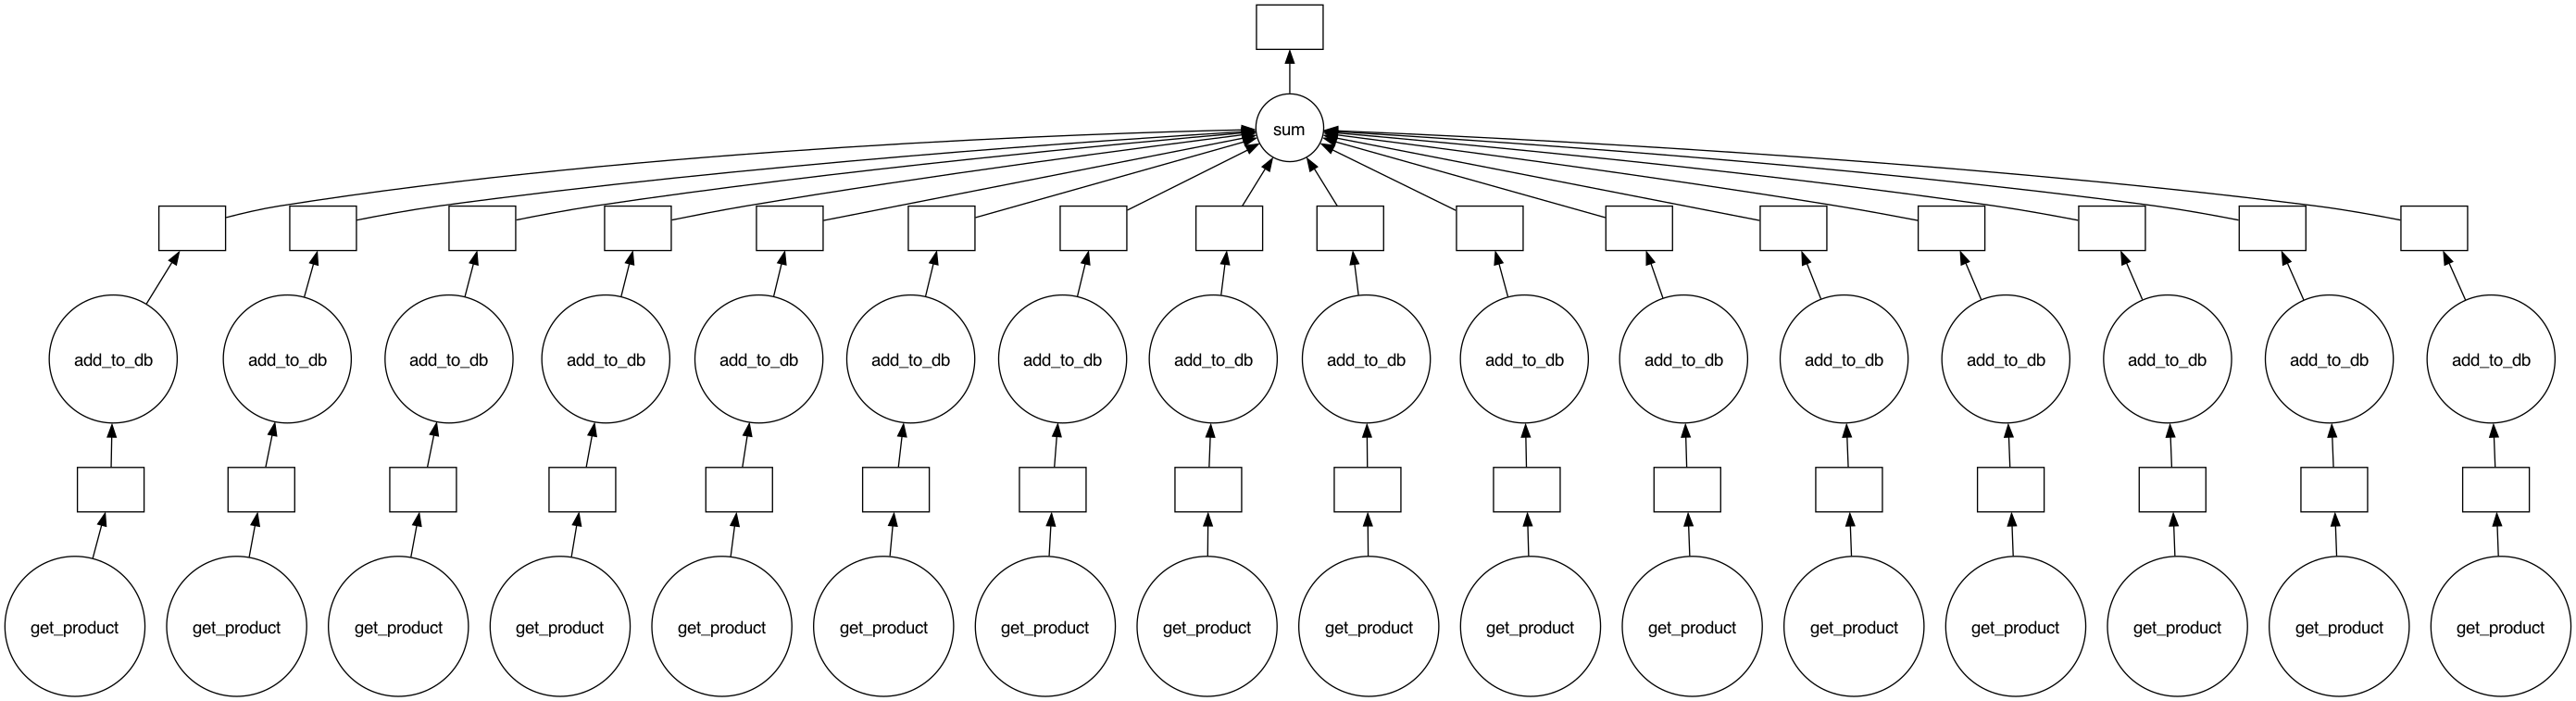

In [ ]:
sum_price_delayed.visualize()

In [ ]:
%%time
sum_price_delayed.compute()

Added Samsung Universe 9 to db
Added Huawei P30 to db
Added iPhone 9 to db
Added OPPOF19 to db
Added Hyaluronic Acid Serum to db
Added iPhone X to db
Added Samsung Galaxy Book to db
Added HP Pavilion 15-DK1056WM to db
Added Microsoft Surface Laptop 4 to db
Added Brown Perfume to db
Added perfume Oil to db
Added Fog Scent Xpressio Perfume to db
Added Non-Alcoholic Concentrated Perfume Oil to db
Added MacBook Pro to db
Added Infinix INBOOK to db
Added Eau De Perfume Spray to db
CPU times: user 1.17 s, sys: 370 ms, total: 1.54 s
Wall time: 18.5 s


10656

<p class="task" id="7"></p>

7\. Перестройте граф вычислений таким образом, чтобы на вход `add_to_db` передавалось сразу по 4 товара. Граф вычислений должен иметь следующий вид:

![image.png](attachment:image.png)

Используя построенный граф, посчитайте общую сумму добавленных товаров и выведите ее на экран. Замерьте время выполнения данного решения.

В качестве демонстрации вставьте скриншот графа в процессе вычислений из дэшборда или результат работы метода `visualize`.

In [ ]:
products_delayed = [get_product_delayed(i) for i in range(1, 17)]
sum_delayed = delayed(sum)
sum_price_delayed_2 = sum_delayed([add_to_db_delayed(*products_delayed[i:i+4]) for i in range(0, 16, 4)])

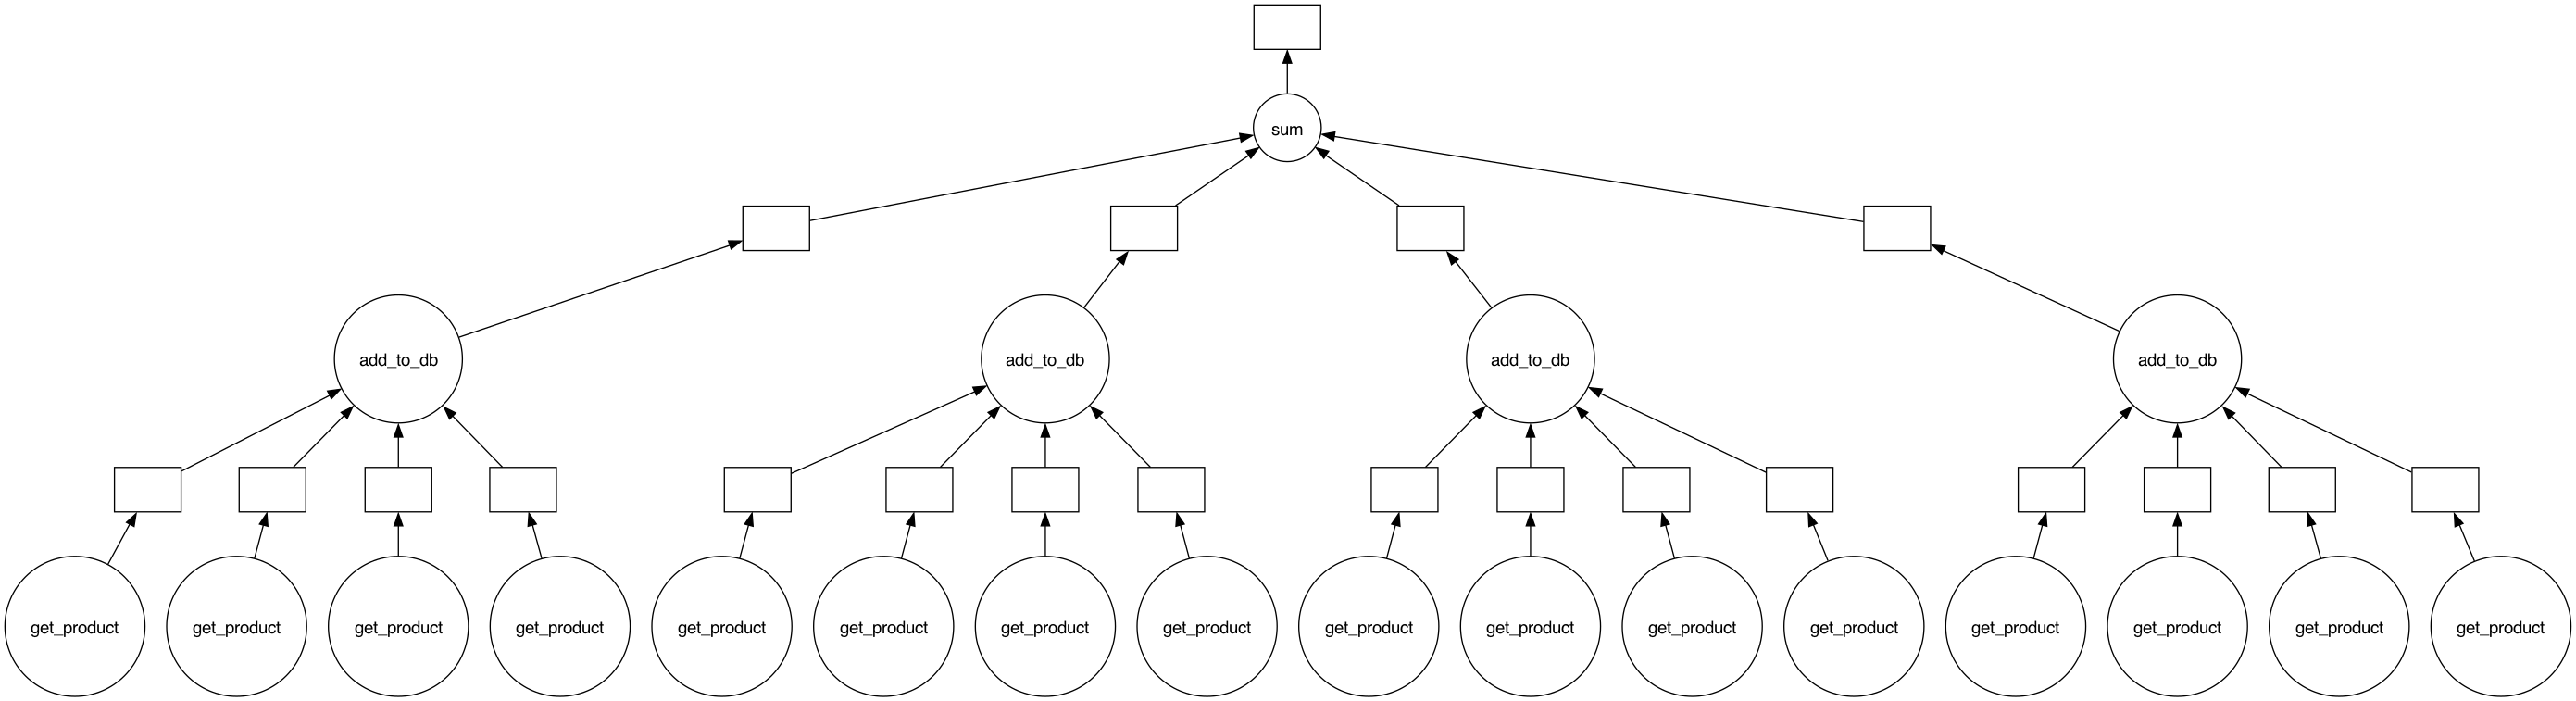

In [ ]:
sum_price_delayed_2.visualize()

In [ ]:
%%time
sum_price_delayed_2.compute()

Added Fog Scent Xpressio Perfume to db
Added Non-Alcoholic Concentrated Perfume Oil to db
Added Eau De Perfume Spray to db
Added Hyaluronic Acid Serum to db
Added Huawei P30 to db
Added MacBook Pro to db
Added Samsung Galaxy Book to db
Added Microsoft Surface Laptop 4 to db
Added Infinix INBOOK to db
Added HP Pavilion 15-DK1056WM to db
Added perfume Oil to db
Added Brown Perfume to db
Added iPhone 9 to db
Added iPhone X to db
Added Samsung Universe 9 to db
Added OPPOF19 to db
CPU times: user 354 ms, sys: 101 ms, total: 455 ms
Wall time: 7.97 s


10656